In [46]:
from pyspark import SparkContext
print(SparkContext._active_spark_context)

<SparkContext master=local[*] appName=Amazon Reviews>


In [47]:
from pyspark.sql import SparkSession

# Stop any existing SparkContext (if accessible)
try:
    spark.stop()
except:
    pass

# Create a brand new SparkSession
spark = (SparkSession.builder
    .appName("Amazon Reviews")
    .master("local[*]")   # Force a new local context
    .config("spark.hadoop.fs.defaultFS", "hdfs://namenode:9000")
    .getOrCreate())

In [48]:
df = spark.read.csv(
    "hdfs://namenode:9000/amazon_reviews/train.csv",
    header=True,
    inferSchema=True
)

### Basic Preprocessing

In [49]:
df = df.toDF("polarity", "review_heading", "review_body")

df.show(5)

+--------+--------------------+--------------------+
|polarity|      review_heading|         review_body|
+--------+--------------------+--------------------+
|       2|The best soundtra...|I'm reading a lot...|
|       2|            Amazing!|"This soundtrack ...|
|       2|Excellent Soundtrack|I truly like this...|
|       2|Remember, Pull Yo...|If you've played ...|
|       2|an absolute maste...|I am quite sure a...|
+--------+--------------------+--------------------+
only showing top 5 rows


### Change 1 for Positive and 0 for Negative

In [50]:
from pyspark.sql.functions import when

df = df.withColumn(
    "label",
    when(df.polarity == 2, 1).otherwise(0)
)

### Combine Text

In [51]:
from pyspark.sql.functions import concat_ws

df = df.withColumn(
    "text",
    concat_ws(" ", df.review_heading, df.review_body)
)

## EDA

In [52]:
df.count()

3599999

In [53]:
df.printSchema()

root
 |-- polarity: integer (nullable = true)
 |-- review_heading: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- label: integer (nullable = false)
 |-- text: string (nullable = false)



In [54]:
df.describe().show()

+-------+------------------+--------------------+--------------------+-------------------+--------------------+
|summary|          polarity|      review_heading|         review_body|              label|                text|
+-------+------------------+--------------------+--------------------+-------------------+--------------------+
|  count|           3599999|             3599951|             3599986|            3599999|             3599999|
|   mean|1.4999998611110725|                 NaN|                NULL|0.49999986111107253|                NULL|
| stddev|0.5000000694444602|                 NaN|                NULL|   0.50000006944446|                NULL|
|    min|                 1|The Worst Thing ...|this is the best...|                  0|The Worst Thing ...|
|    max|                 2|         ♦ LOVE IT ♦|…were Marvin and ...|                  1|♦ LOVE IT ♦ Wow I...|
+-------+------------------+--------------------+--------------------+-------------------+--------------

### Check Missing Values

In [55]:
from pyspark.sql.functions import col, sum

df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show()

+--------+--------------+-----------+-----+----+
|polarity|review_heading|review_body|label|text|
+--------+--------------+-----------+-----+----+
|       0|            48|         13|    0|   0|
+--------+--------------+-----------+-----+----+



### Check Number of Labels

In [56]:
df.groupBy("label").count().withColumnRenamed("count", "num_reviews").show()

+-----+-----------+
|label|num_reviews|
+-----+-----------+
|    1|    1799999|
|    0|    1800000|
+-----+-----------+



In [57]:
from pyspark.sql.functions import lower, regexp_replace

clean_df = df.withColumn("text", lower(col("text")))
clean_df = clean_df.withColumn("text", regexp_replace("text", "[^a-zA-Z\\s]", ""))

In [58]:
from pyspark.ml.feature import Tokenizer

tokenizer = Tokenizer(inputCol="text", outputCol="words")
words_df = tokenizer.transform(clean_df)

In [59]:
from pyspark.sql.functions import explode

word_counts = words_df.select(explode(col("words")).alias("word"))

In [60]:
word_counts = word_counts.filter(col("word") != "")

In [61]:
top_words = word_counts.groupBy("word").count().orderBy("count", ascending=False)

top_words.show(20)

+----+--------+
|word|   count|
+----+--------+
| the|12761476|
| and| 6833610|
|   i| 6756222|
|   a| 6501846|
|  to| 6224992|
|  it| 5187061|
|  of| 5052197|
|this| 4788446|
|  is| 4487308|
|  in| 2948544|
| for| 2875921|
|that| 2466598|
| was| 2232568|
| not| 2120269|
| you| 1974441|
|with| 1867041|
| but| 1812922|
|  on| 1808731|
|book| 1772849|
|  my| 1708664|
+----+--------+
only showing top 20 rows


### Top Words

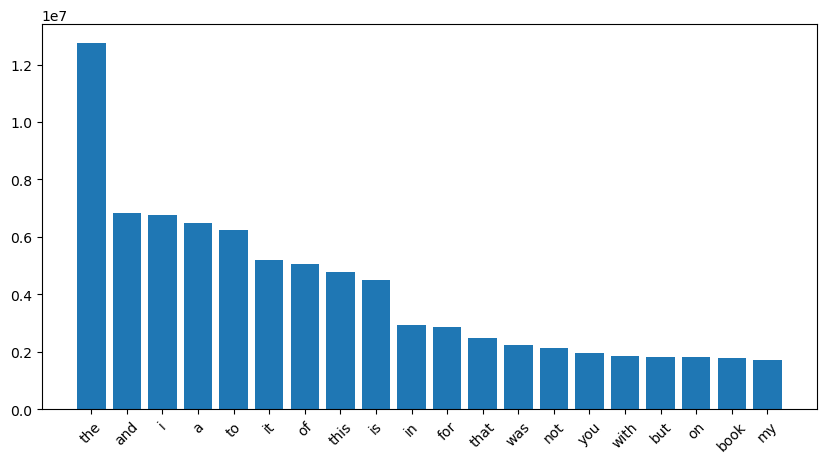

In [62]:
import matplotlib.pyplot as plt

pdf = top_words.limit(20).toPandas()

plt.figure(figsize=(10,5))
plt.bar(pdf["word"], pdf["count"])
plt.xticks(rotation=45)
plt.show()

## Preprocessing

### TF-IDF

In [67]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.sql.functions import concat_ws

df = df.withColumn("text", concat_ws(" ", df.review_heading, df.review_body))

tokenizer = RegexTokenizer(inputCol="text", outputCol="words", pattern="\\W", toLowercase=True)

stopwords = StopWordsRemover(inputCol="words", outputCol="filtered")

tf = HashingTF(inputCol="filtered", outputCol="rawFeatures", numFeatures=10000)

idf = IDF(inputCol="rawFeatures", outputCol="features", minDocFreq=2)

pipeline = Pipeline(stages=[
    tokenizer,
    stopwords,
    tf,
    idf
])
model = pipeline.fit(df)
df_tfidf = model.transform(df)

In [68]:
df_tfidf.select("features", "label").show(5, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------